# Adidas US Sales: Data Cleaning and Exploratory Analysis

Reads the raw Excel export, cleans it, and writes a PostgreSQL-ready CSV.

**Input:** `Adidas US Sales Dataset (Raw).xlsx`
**Output:** `adidas_cleaned_dataset.csv`

Install dependencies with `pip install -r requirements.txt`, then run all cells.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAW_FILE = 'Adidas US Sales Dataset (Raw).xlsx'
CLEAN_FILE = 'adidas_cleaned_dataset.csv'

NUMERIC_COLS = [
    'price_per_unit', 'units_sold', 'total_sales',
    'operating_profit', 'operating_margin',
]

## 1. Load the raw dataset

The export carries four rows of report metadata above the header, and a blank
leading column, so both are skipped on read.

In [2]:
df = pd.read_excel(
    RAW_FILE,
    skiprows=4,                           # report metadata above the header
    usecols=lambda c: c != 'Unnamed: 0',  # blank leading column
)

print('Shape:', df.shape)
display(df.head())

Shape: (9648, 13)


,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,In-store
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,In-store


## 2. Normalise column names

Lowercase with underscores, so the columns can be used as PostgreSQL
identifiers without quoting.

In [3]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(' ', '_')
    .str.replace('-', '_')
    .str.lower()
)

print(list(df.columns))

['retailer', 'retailer_id', 'invoice_date', 'region', 'state', 'city', 'product', 'price_per_unit', 'units_sold', 'total_sales', 'operating_profit', 'operating_margin', 'sales_method']


## 3. Fix data types, then handle missing values

Order matters here. `pd.to_numeric(..., errors='coerce')` turns anything
unparseable into `NaN`, so it has to run *before* the missing-value pass,
otherwise those newly created gaps go unfilled.

In [4]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], errors='coerce')

for col in NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Coerced to NaN by type conversion:')
print(df[NUMERIC_COLS + ['invoice_date']].isna().sum().to_string())

before = len(df)
df = df.drop_duplicates()
print(f'\nDropped {before - len(df)} duplicate rows, {len(df)} remain')

df = df.fillna({
    'operating_margin': df['operating_margin'].median(),
    'sales_method': 'Unknown',
})

print('Remaining nulls:', int(df.isna().sum().sum()))

Coerced to NaN by type conversion:
price_per_unit      0
units_sold          0
total_sales         0
operating_profit    0
operating_margin    0
invoice_date        0

Dropped 0 duplicate rows, 9648 remain
Remaining nulls: 0


## 4. Derive date parts

`year` and `month` are materialised as columns so the SQL layer can group on
them without date functions.

In [5]:
df['year'] = df['invoice_date'].dt.year
df['month'] = df['invoice_date'].dt.month_name()

print('Date range:', df['invoice_date'].min().date(), 'to', df['invoice_date'].max().date())
print(df.groupby('year').size().to_string())

Date range: 2020-01-01 to 2021-12-31
year
2020    1302
2021    8346


## 5. Outlier scan

Flagged by the interquartile rule but deliberately kept: these are large
wholesale orders, not data errors.

In [6]:
for col in NUMERIC_COLS:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f'{col}: {outliers} outliers (kept for analysis)')

price_per_unit: 104 outliers (kept for analysis)
units_sold: 508 outliers (kept for analysis)
total_sales: 653 outliers (kept for analysis)
operating_profit: 706 outliers (kept for analysis)
operating_margin: 63 outliers (kept for analysis)


## 6. Statistical summary

In [7]:
print('--- Describe ---')
print(df[NUMERIC_COLS].describe().T)

print('\n--- Mean, median, mode ---')
for col in NUMERIC_COLS:
    print(
        f'{col}: mean={df[col].mean():.2f}, '
        f'median={df[col].median():.2f}, '
        f'mode={df[col].mode()[0]:.2f}'
    )

print('\n--- Correlation ---')
print(df[NUMERIC_COLS].corr().round(3))

--- Describe ---
                   count          mean            std  min        25%  \
price_per_unit    9648.0     45.216625      14.705397  7.0    35.0000   
units_sold        9648.0    256.930037     214.252030  0.0   106.0000   
total_sales       9648.0  93273.437500  141916.016727  0.0  4254.5000   
operating_profit  9648.0  34425.244761   54193.113713  0.0  1921.7525   
operating_margin  9648.0      0.422991       0.097197  0.1     0.3500   

                      50%        75%       max  
price_per_unit      45.00      55.00     110.0  
units_sold         176.00     350.00    1275.0  
total_sales       9576.00  150000.00  825000.0  
operating_profit  4371.42   52062.50  390000.0  
operating_margin     0.41       0.49       0.8  

--- Mean, median, mode ---
price_per_unit: mean=45.22, median=45.00, mode=50.00
units_sold: mean=256.93, median=176.00, mode=225.00
total_sales: mean=93273.44, median=9576.00, mode=100000.00
operating_profit: mean=34425.24, median=4371.42, mode=2100

## 7. Key business metrics

These are the whole-dataset figures, across all six retailers. The Power BI
dashboard has a retailer slicer, so any KPI read off a filtered dashboard view
will be much smaller than these. The per-retailer table below exists to make
that difference explicit.

In [8]:
print('--- All retailers ---')
print(f"Total revenue:           {df['total_sales'].sum():,.2f}")
print(f"Total operating profit:  {df['operating_profit'].sum():,.2f}")
print(f"Total units sold:        {df['units_sold'].sum():,.0f}")
print(f"Average operating margin:{df['operating_margin'].mean() * 100:6.2f}%")
print(f"Average price per unit:   {df['price_per_unit'].mean():.2f}")

--- All retailers ---
Total revenue:           899,902,125.00
Total operating profit:  332,134,761.45
Total units sold:        2,478,861
Average operating margin: 42.30%
Average price per unit:   45.22


In [9]:
by_retailer = df.groupby('retailer').agg(
    revenue_m=('total_sales', lambda s: s.sum() / 1e6),
    profit_m=('operating_profit', lambda s: s.sum() / 1e6),
    units_k=('units_sold', lambda s: s.sum() / 1e3),
    avg_margin_pct=('operating_margin', lambda s: s.mean() * 100),
    avg_price=('price_per_unit', 'mean'),
).sort_values('revenue_m', ascending=False).round(2)

display(by_retailer)

,revenue_m,profit_m,units_k,avg_margin_pct,avg_price
retailer,,,,,
West Gear,242.96,85.67,625.26,41.79,46.74
Foot Locker,220.09,80.72,604.37,41.79,44.78
Sports Direct,182.47,74.33,557.64,44.49,42.05
Kohl's,102.11,36.81,287.38,41.93,44.61
Amazon,77.70,28.82,197.99,41.79,48.76
Walmart,74.56,25.78,206.22,40.65,47.18


## 8. Export for PostgreSQL

In [10]:
df.to_csv(CLEAN_FILE, index=False)
print(f'Wrote {CLEAN_FILE}: {df.shape[0]} rows x {df.shape[1]} columns')

Wrote adidas_cleaned_dataset.csv: 9648 rows x 15 columns


## 9. Exploratory summaries

In [11]:
print('Revenue and profit by region (millions):')
print(
    df.groupby('region')
    .agg(revenue=('total_sales', 'sum'), profit=('operating_profit', 'sum'))
    .div(1e6).round(2).sort_values('revenue', ascending=False)
    .to_string()
)

print('\nRevenue by product (millions):')
print(df.groupby('product')['total_sales'].sum().div(1e6).round(2).sort_values(ascending=False).to_string())

print('\nTop 10 cities by revenue (millions):')
print(df.groupby('city')['total_sales'].sum().div(1e6).round(2).nlargest(10).to_string())

method = df.groupby('sales_method')['total_sales'].sum()
print('\nShare of revenue by sales method (%):')
print((method / method.sum() * 100).round(1).to_string())

Revenue and profit by region (millions):
           revenue  profit
region                    
West        269.94   89.61
Northeast   186.32   68.02
Southeast   163.17   60.56
South       144.66   61.14
Midwest     135.80   52.81

Revenue by product (millions):
product
Men's Street Footwear        208.83
Women's Apparel              179.04
Men's Athletic Footwear      153.67
Women's Street Footwear      128.00
Men's Apparel                123.73
Women's Athletic Footwear    106.63

Top 10 cities by revenue (millions):
city
Charleston       39.97
New York         39.80
San Francisco    34.54
Miami            31.60
Portland         30.55
Orlando          27.68
Seattle          26.33
Los Angeles      25.63
Houston          25.46
Albany           24.43

Share of revenue by sales method (%):
sales_method
In-store    39.6
Online      27.5
Outlet      32.8


### Coverage caveat on year-over-year growth

2020 and 2021 are not comparable. 2020 holds 1,302 rows across five retailers,
2021 holds 8,346 across six, and Amazon has no 2020 rows at all. Most of the
apparent year-over-year jump is retailer coverage widening, not organic growth,
so the yearly totals below should not be read as a growth rate.

In [12]:
coverage = df.groupby('year').agg(
    rows=('total_sales', 'size'),
    revenue_m=('total_sales', lambda s: s.sum() / 1e6),
    retailers=('retailer', 'nunique'),
    months=('invoice_date', lambda s: s.dt.month.nunique()),
).round(2)

display(coverage)
display(pd.crosstab(df['retailer'], df['year']))

,rows,revenue_m,retailers,months
year,,,,
2020,1302,182.08,5,12
2021,8346,717.82,6,12


year,2020,2021
retailer,,
Amazon,0,949
Foot Locker,337,2300
Kohl's,8,1022
Sports Direct,106,1926
Walmart,216,410
West Gear,635,1739


## 10. Visualisations

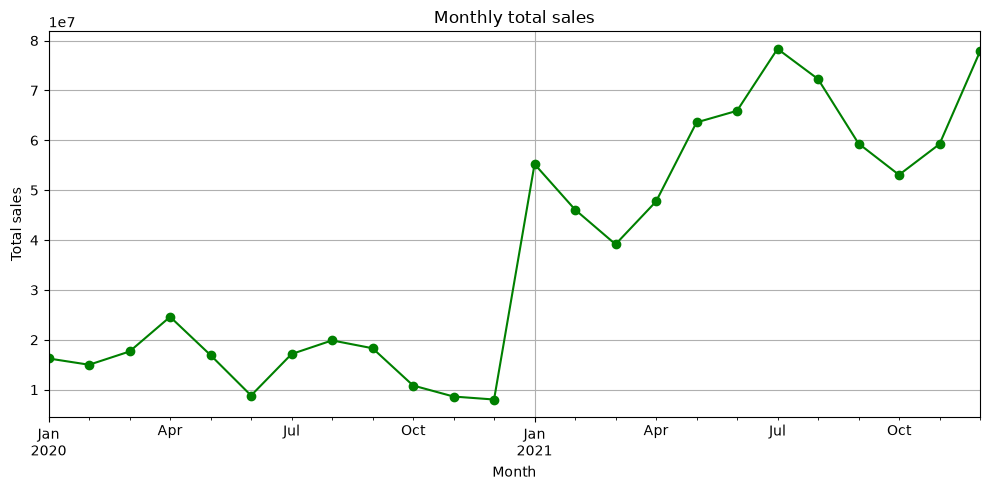

In [13]:
monthly_sales = df.groupby(df['invoice_date'].dt.to_period('M'))['total_sales'].sum()

plt.figure(figsize=(10, 5))
monthly_sales.plot(marker='o', color='green')
plt.title('Monthly total sales')
plt.xlabel('Month')
plt.ylabel('Total sales')
plt.grid(True)
plt.tight_layout()
plt.show()

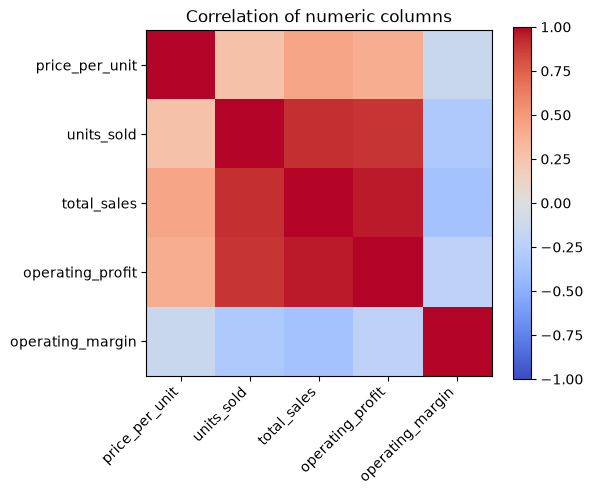

In [14]:
corr = df[NUMERIC_COLS].corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation of numeric columns')
plt.tight_layout()
plt.show()

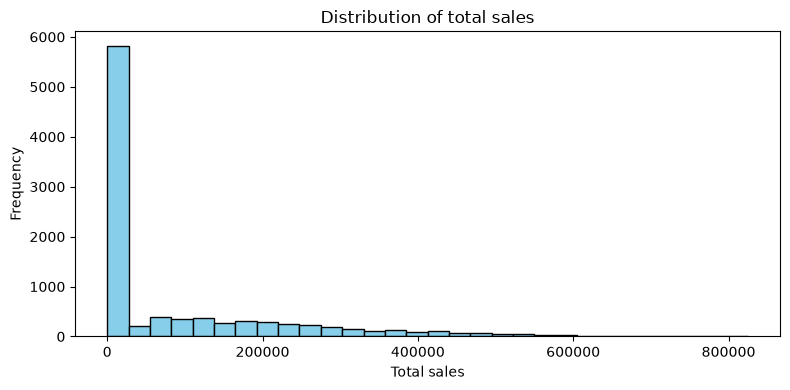

In [15]:
plt.figure(figsize=(8, 4))
plt.hist(df['total_sales'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of total sales')
plt.xlabel('Total sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()